# SIMPLE MULTI-MODEL AI AGENT

In [ ]:
!pip install langchain-google-genai langchain_tavily langchain_community 

In [ ]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.graph.message import MessagesState
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver
# from langchain_groq import ChatGroq

In [ ]:
os.environ['TAVILY_API_KEY'] = "xxxxxxxxxxxxxxxxxxxxx"

In [ ]:
os.environ['GOOGLE_API_KEY'] = "xxxxxxxxxxxxxxx"
llm = ChatGoogleGenerativeAI(model= "gemini-2.5-flash",
                            temperature=0.4
                             )

In [ ]:
# from langchain.chat_models import init_chat_model
# os.environ["GROQ_API_KEY"]="xxxxxxxxxxxxxxxxx"
# llm=init_chat_model("groq:llama-3.1-8b-instant")
# llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7af19a3823c0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7af19a2658b0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [ ]:
# Define the state
class AgentState(MessagesState):
    next_agent:str #which agent should go next

In [ ]:
# Create simple tools
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    # Using Tavily for web search
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

In [ ]:
@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    # Simple summary generation
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [ ]:
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""

    messages = state["messages"]

    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")

    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)

    # Return the response and route to writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }


In [ ]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""

    messages = state["messages"]

    # Add system message
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")

    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)

    return {
        "messages": [response],
        "next_agent": "end"
    }

In [ ]:
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]

    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response

    return state

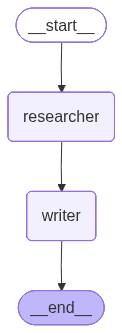

In [ ]:
# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)
workflow.add_node("execute_tools", execute_tools)

# Define flow
workflow.set_entry_point("researcher")
# workflow.add_edge("researcher", "writer")
workflow.add_edge("researcher", "execute_tools")
workflow.add_edge("writer", END)
final_workflow=workflow.compile()

final_workflow

In [ ]:
response = final_workflow.invoke({"messages":"Research about the use case of Yoga for healthcare"})
for r in response['messages']:
  r.pretty_print()

================================ Human Message =================================

Research about the use case of Yoga for healthcare
================================== Ai Message ==================================
Tool Calls:
  search_web (738b1398-c4b4-4eeb-b487-f4c60dba3092)
 Call ID: 738b1398-c4b4-4eeb-b487-f4c60dba3092
  Args:
    query: Yoga for healthcare use cases
================================== Ai Message ==================================
